# 🔬 Μέρος Α2 — Classical Data Augmentation (χωρίς AI)
Data Science Bowl 2018 — Nuclei Segmentation

## 0. Imports & Config

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import warnings
warnings.filterwarnings('ignore')

TRAIN_DIR = Path('./data/raw/train')
AUG_DIR   = Path('./data/augmented')
AUG_DIR.mkdir(parents=True, exist_ok=True)
(AUG_DIR / 'images').mkdir(exist_ok=True)
(AUG_DIR / 'masks').mkdir(exist_ok=True)

IMG_SIZE = 256  # resize όλα σε 256x256
print('Setup complete.')

Setup complete.


## 1. Helper Functions

In [2]:
def load_image_and_mask(train_dir, img_id, target_size=256):
    """
    Φορτώνει εικόνα + συνδυάζει ΟΛΑ τα masks σε ένα binary mask.
    Επιστρέφει (image RGB uint8, mask binary uint8) resize στο target_size.
    """
    img_path = train_dir / img_id / 'images' / f'{img_id}.png'
    img = np.array(Image.open(img_path).convert('RGB'))

    mask_dir = train_dir / img_id / 'masks'
    h, w = img.shape[:2]
    combined = np.zeros((h, w), dtype=np.uint8)
    for mf in sorted(mask_dir.glob('*.png')):
        m = np.array(Image.open(mf).convert('L'))
        combined = np.maximum(combined, (m > 0).astype(np.uint8) * 255)

    img   = cv2.resize(img,   (target_size, target_size), interpolation=cv2.INTER_LINEAR)
    combined = cv2.resize(combined, (target_size, target_size), interpolation=cv2.INTER_NEAREST)
    return img, combined


def show_augmentation(original_img, original_mask, aug_results, title, cols=5):
    """
    Εμφανίζει original + N augmented versions (image πάνω, mask κάτω).
    aug_results: list of (img, mask) tuples
    """
    n = 1 + len(aug_results)
    fig, axes = plt.subplots(2, min(n, cols), figsize=(3 * min(n, cols), 6))
    fig.suptitle(title, fontsize=13, fontweight='bold')

    all_imgs   = [(original_img, original_mask, 'Original')] + \
                 [(r['image'], r['mask'], f'Aug {i+1}') for i, r in enumerate(aug_results)]

    for col, (img, msk, lbl) in enumerate(all_imgs[:cols]):
        axes[0, col].imshow(img)
        axes[0, col].set_title(lbl, fontsize=9)
        axes[0, col].axis('off')
        axes[1, col].imshow(msk, cmap='gray')
        axes[1, col].axis('off')

    axes[0, 0].set_ylabel('Image', fontsize=10)
    axes[1, 0].set_ylabel('Mask',  fontsize=10)
    plt.tight_layout()
    plt.savefig(f'./outputs/aug_{title.replace(" ","_").lower()}.png', dpi=120, bbox_inches='tight')
    plt.show()


# Φόρτωσε ένα sample για visualisation
all_ids = sorted(os.listdir(TRAIN_DIR))
sample_id = all_ids[0]
sample_img, sample_mask = load_image_and_mask(TRAIN_DIR, sample_id)
print(f'Sample image shape: {sample_img.shape}')
print(f'Sample mask  shape: {sample_mask.shape}')

Sample image shape: (256, 256, 3)
Sample mask  shape: (256, 256)


## 2. Τεχνική 1 — Geometric Transforms
### Flip + Rotation
**Γιατί:** Οι πυρήνες δεν έχουν προτιμώμενο προσανατολισμό — ένας πυρήνας στραμμένος 90° είναι ακριβώς το ίδιο έγκυρος. Αυτές οι τεχνικές δεν αλλάζουν τη βιολογική δομή.

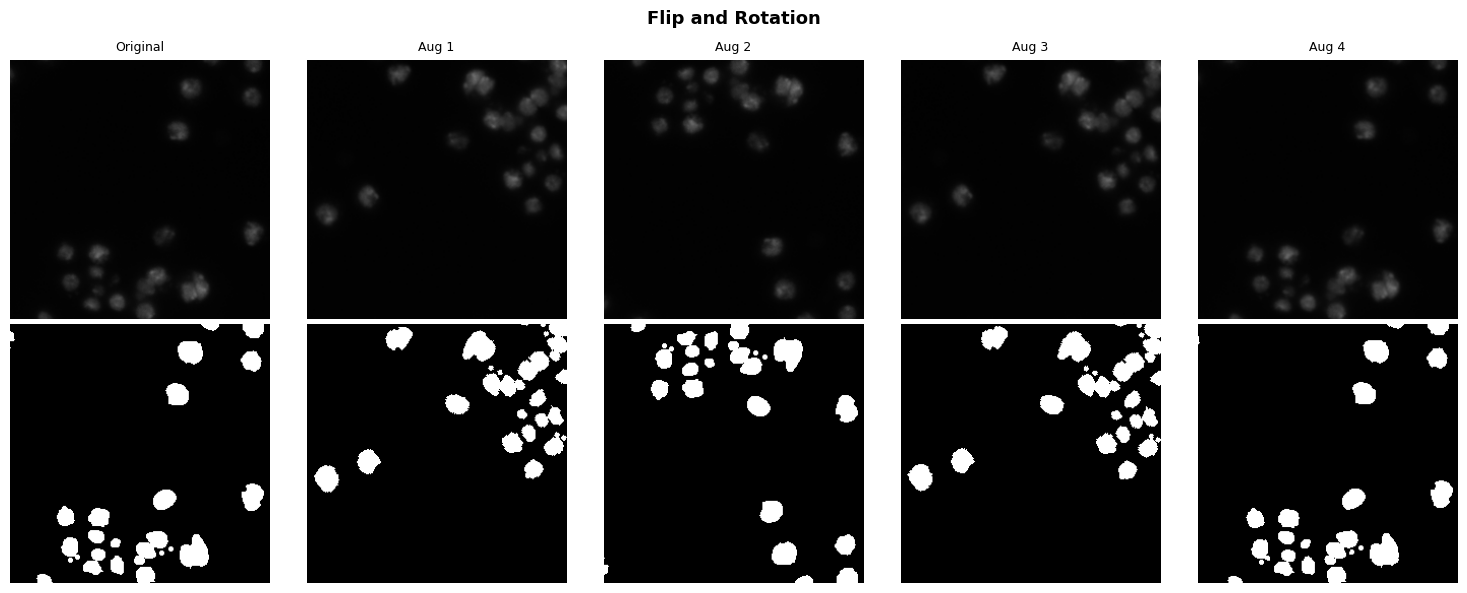

In [3]:
flip_rotate_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=1.0),
    A.Rotate(limit=45, p=0.7, border_mode=cv2.BORDER_REFLECT),
])

results = [flip_rotate_transform(image=sample_img, mask=sample_mask) for _ in range(4)]
show_augmentation(sample_img, sample_mask, results, 'Flip and Rotation')

## 3. Τεχνική 2 — Elastic Deformation
**Γιατί:** Μιμείται την ελαστική παραμόρφωση που συμβαίνει φυσικά στους ιστούς κατά την παρασκευή του δείγματος. Είναι από τις πιο αποτελεσματικές τεχνικές για biomedical segmentation (χρησιμοποιήθηκε στο original U-Net paper).

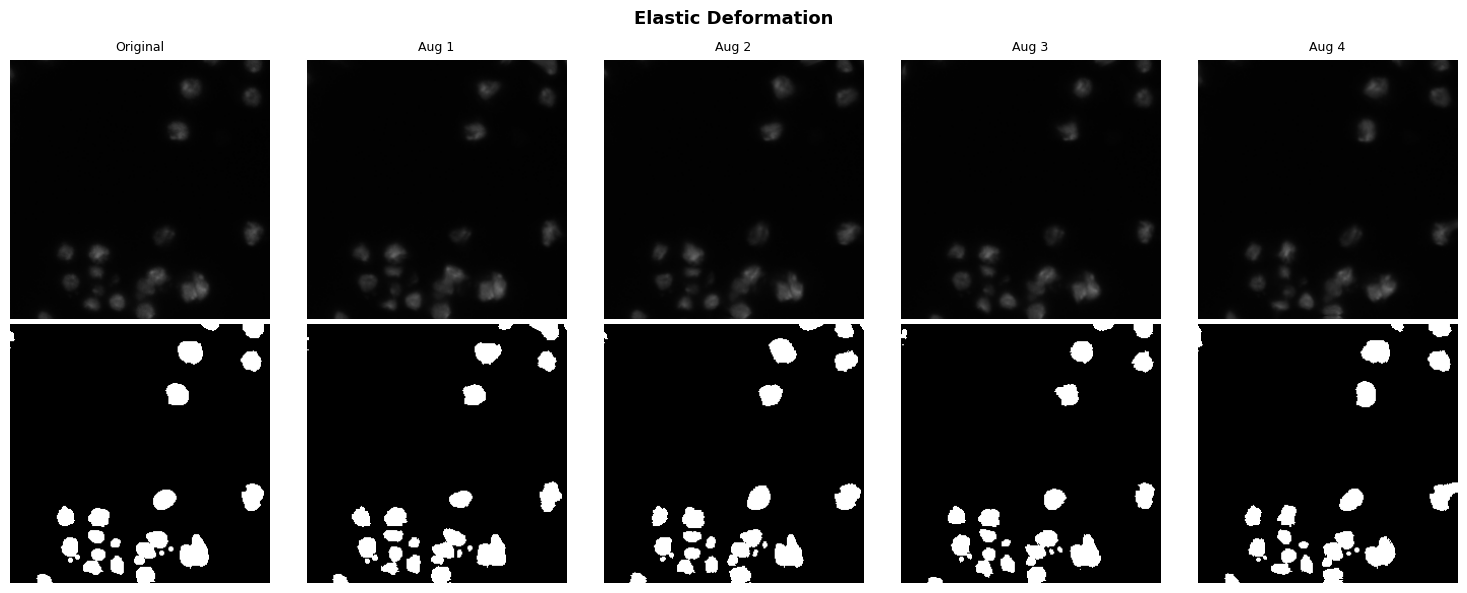

In [4]:
elastic_transform = A.Compose([
    A.ElasticTransform(
        alpha=120,
        sigma=120 * 0.05,
        alpha_affine=120 * 0.03,
        p=1.0,
        border_mode=cv2.BORDER_REFLECT
    ),
])

results = [elastic_transform(image=sample_img, mask=sample_mask) for _ in range(4)]
show_augmentation(sample_img, sample_mask, results, 'Elastic Deformation')

## 4. Τεχνική 3 — Photometric: Brightness / Contrast / Gamma
**Γιατί:** Διαφορετικά microscopes, διαφορετικά exposure settings, και διαφορετικές χρώσεις παράγουν εικόνες με διαφορετική φωτεινότητα και contrast. Το μοντέλο πρέπει να είναι ανεξάρτητο από αυτές τις παραμέτρους.

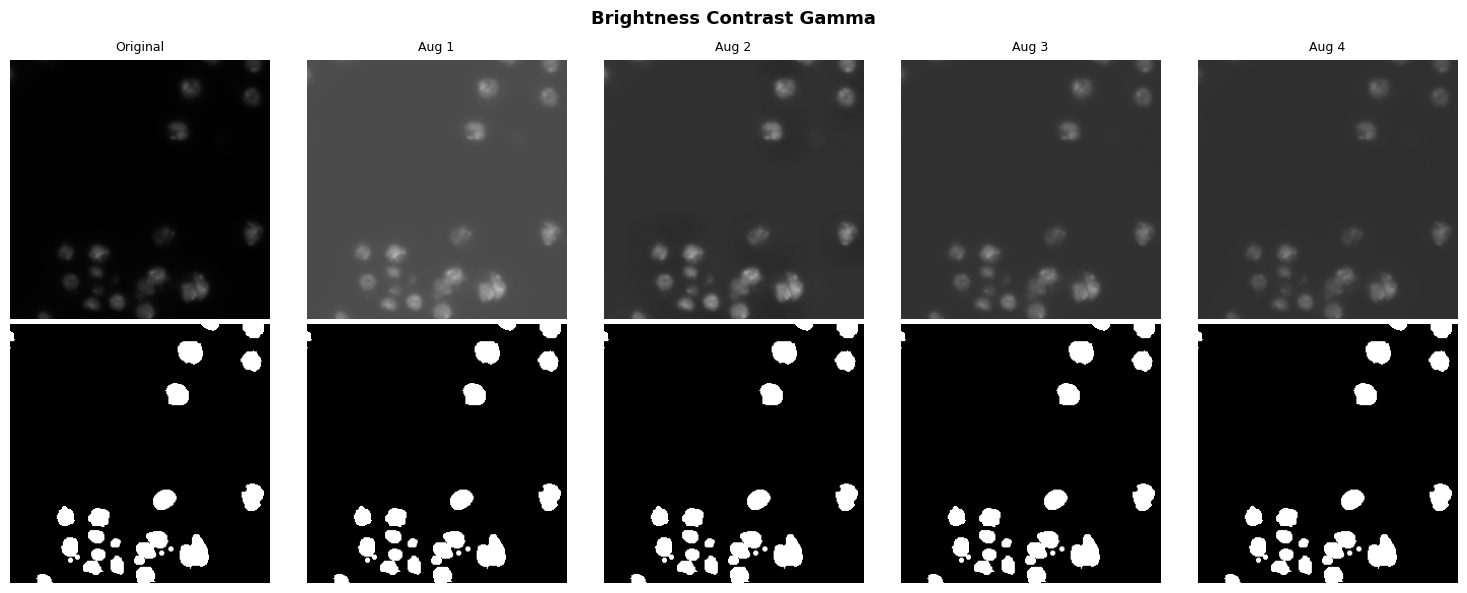

In [5]:
photometric_transform = A.Compose([
    A.RandomBrightnessContrast(
        brightness_limit=0.3,
        contrast_limit=0.3,
        p=1.0
    ),
    A.RandomGamma(gamma_limit=(70, 130), p=0.5),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
])

results = [photometric_transform(image=sample_img, mask=sample_mask) for _ in range(4)]
show_augmentation(sample_img, sample_mask, results, 'Brightness Contrast Gamma')

## 5. Τεχνική 4 — Noise + Blur
**Γιατί:** Τα microscopy images έχουν συχνά Gaussian noise λόγω του detector. Το blur μιμείται defocus. Το μοντέλο πρέπει να μπορεί να αναγνωρίζει πυρήνες και σε μη ιδανικές συνθήκες λήψης.

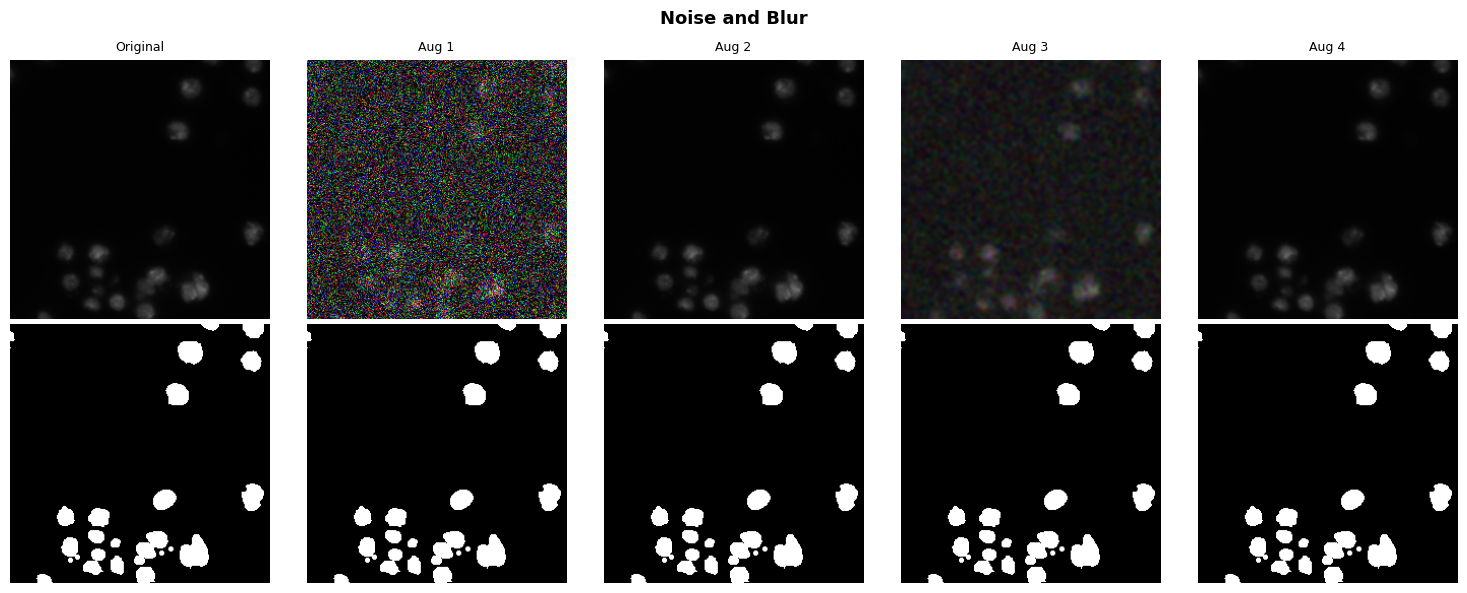

In [6]:
noise_blur_transform = A.Compose([
    A.OneOf([
        A.GaussNoise(var_limit=(10.0, 50.0), p=1.0),
        A.ISONoise(color_shift=(0.01, 0.05), intensity=(0.1, 0.5), p=1.0),
    ], p=0.8),
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 7), p=1.0),
        A.MedianBlur(blur_limit=5, p=1.0),
        A.MotionBlur(blur_limit=7, p=1.0),
    ], p=0.5),
])

results = [noise_blur_transform(image=sample_img, mask=sample_mask) for _ in range(4)]
show_augmentation(sample_img, sample_mask, results, 'Noise and Blur')

## 6. Τεχνική 5 — Random Crop + Scale
**Γιατί:** Δημιουργεί scale invariance — το μοντέλο μαθαίνει να αναγνωρίζει πυρήνες σε διαφορετικές κλίμακες. Επίσης βοηθά στο να εστιάζει σε τμήματα της εικόνας με πολλούς πυρήνες.

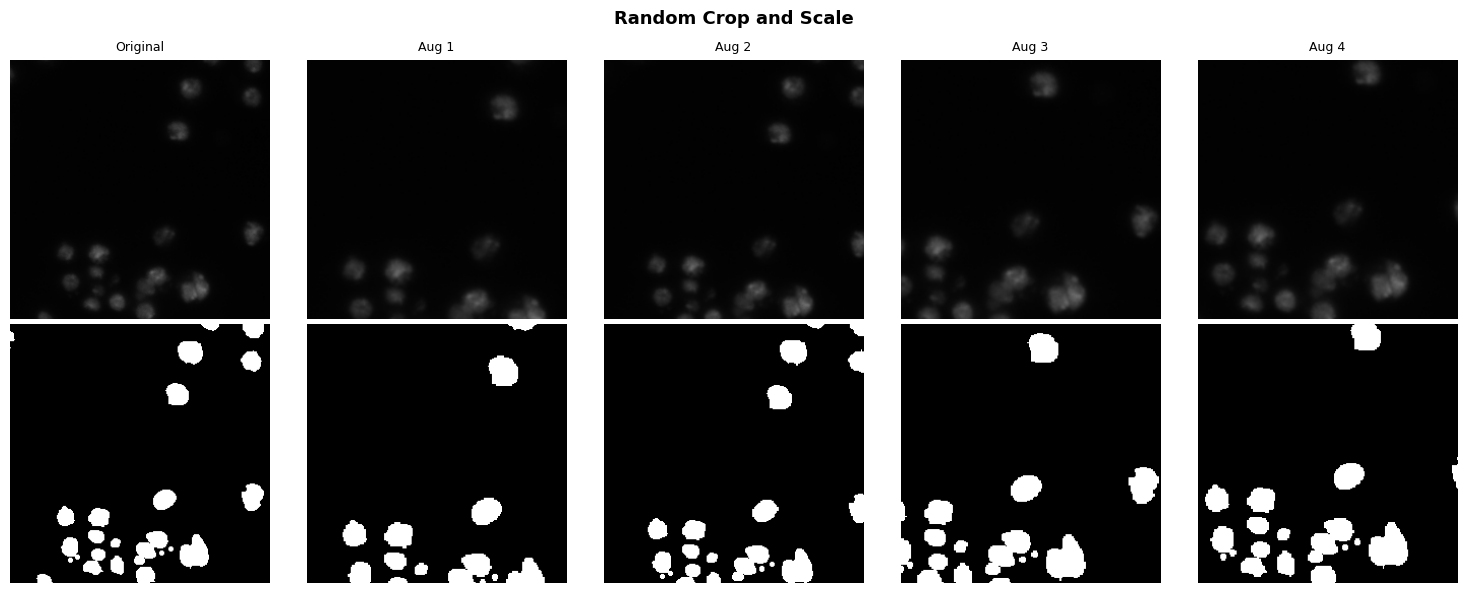

In [10]:
crop_scale_transform = A.Compose([
    A.OneOf([
        # Needs height and width
        A.RandomCrop(height=192, width=192, p=1.0), 
        
        # Needs size tuple
        A.RandomResizedCrop(
            size=(IMG_SIZE, IMG_SIZE), 
            scale=(0.5, 1.0), ratio=(0.75, 1.33), p=1.0
        ),
    ], p=1.0),
    
    # Needs height and width
    A.Resize(height=IMG_SIZE, width=IMG_SIZE), 
])

results = [crop_scale_transform(image=sample_img, mask=sample_mask) for _ in range(4)]
show_augmentation(sample_img, sample_mask, results, 'Random Crop and Scale')

## 7. Τεχνική 6 — Grid Distortion + Optical Distortion
**Γιατί:** Μιμείται παραμορφώσεις από τον φακό του microscope (lens distortion) και ανομοιομορφίες στη φυσική κατανομή του δείγματος.

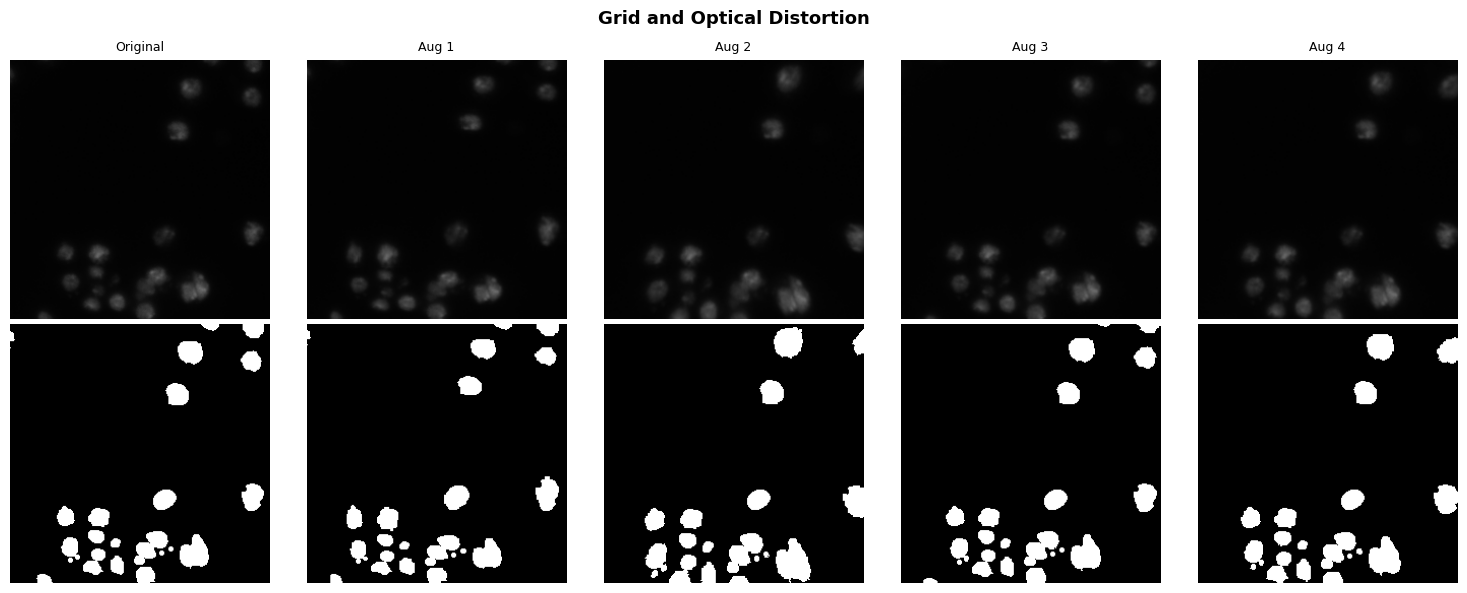

In [11]:
distortion_transform = A.Compose([
    A.OneOf([
        A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0,
                         border_mode=cv2.BORDER_REFLECT),
        A.OpticalDistortion(distort_limit=0.3, shift_limit=0.05, p=1.0,
                            border_mode=cv2.BORDER_REFLECT),
    ], p=1.0),
])

results = [distortion_transform(image=sample_img, mask=sample_mask) for _ in range(4)]
show_augmentation(sample_img, sample_mask, results, 'Grid and Optical Distortion')

## 8. Τεχνική 7 — Stain Normalization (Macenko)
**Γιατί:** Ειδικά για histology images (H&E staining), η χρώση μπορεί να ποικίλει σημαντικά. Η κανονικοποίηση Macenko μετατρέπει όλες τις εικόνες σε κοινό color space, ενώ η stain augmentation δημιουργεί τεχνητά variations.

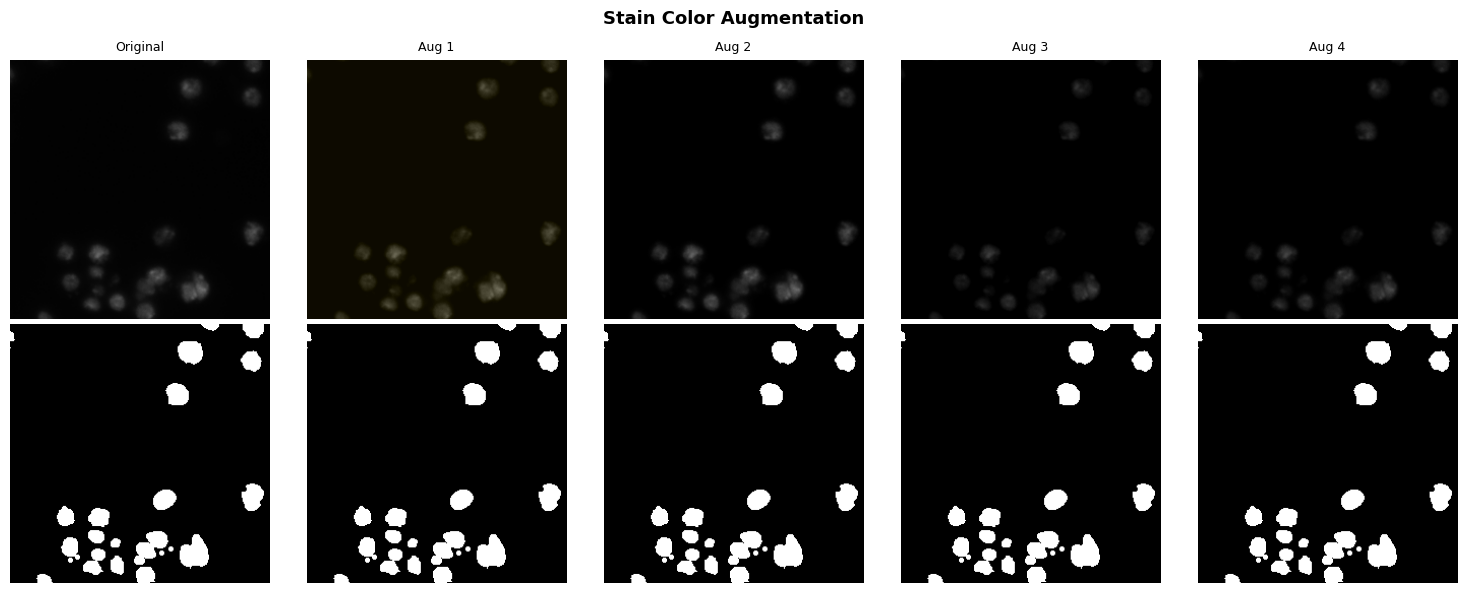

In [12]:
# Stain augmentation μέσω HueSaturation (proxy για stain variation)
stain_transform = A.Compose([
    A.HueSaturationValue(
        hue_shift_limit=20,
        sat_shift_limit=30,
        val_shift_limit=20,
        p=1.0
    ),
    A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.5),
    A.ColorJitter(
        brightness=0.2, contrast=0.2,
        saturation=0.2, hue=0.1, p=0.5
    ),
])

# Χρησιμοποίησε color image για να φανεί το effect
color_ids = [i for i in all_ids
             if np.array(Image.open(TRAIN_DIR / i / 'images' / f'{i}.png')).ndim == 3]

if color_ids:
    c_img, c_mask = load_image_and_mask(TRAIN_DIR, color_ids[0])
    results = [stain_transform(image=c_img, mask=c_mask) for _ in range(4)]
    show_augmentation(c_img, c_mask, results, 'Stain Color Augmentation')
else:
    print('Δεν βρέθηκαν color images στο sample.')

## 9. Pipeline Σύνθεσης — Όλα Μαζί
Ο τελικός augmentation pipeline που χρησιμοποιείται στο training.

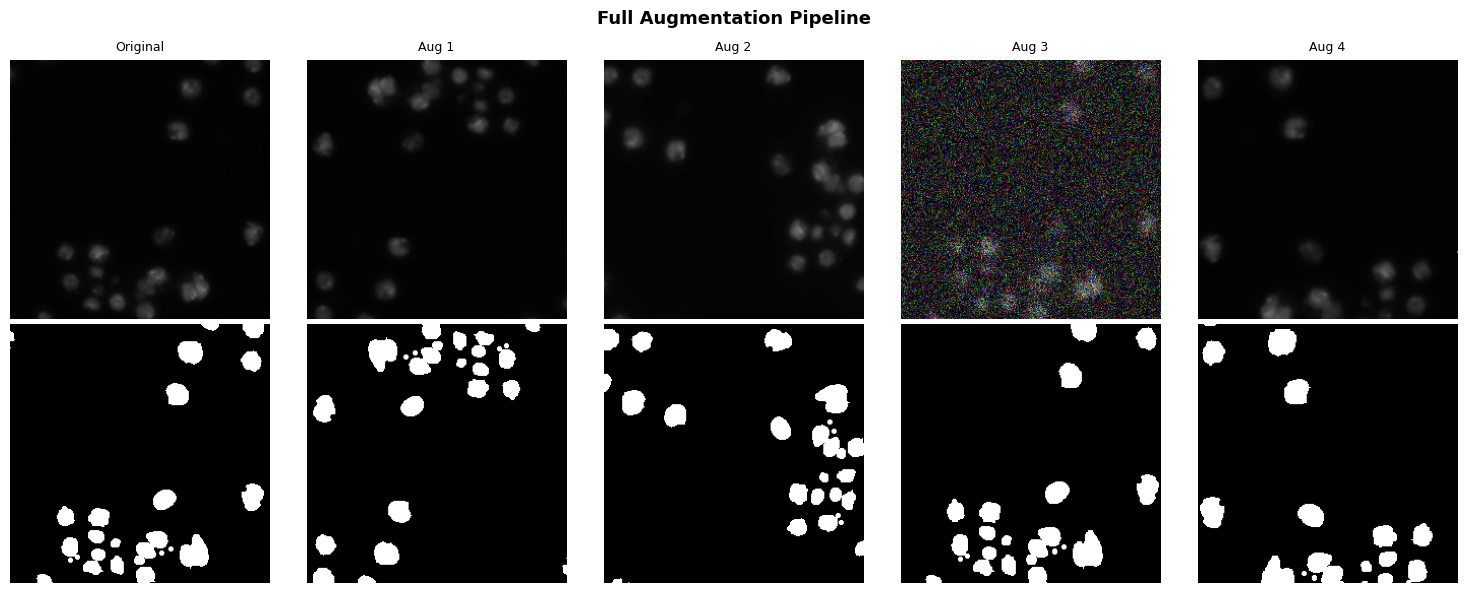

In [14]:
FULL_AUGMENTATION_PIPELINE = A.Compose([
    # --- Geometric ---
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Rotate(limit=30, p=0.4, border_mode=cv2.BORDER_REFLECT),

    # --- Elastic / Distortion ---
    A.OneOf([
        A.ElasticTransform(alpha=80, sigma=80*0.05, alpha_affine=80*0.03,
                           border_mode=cv2.BORDER_REFLECT, p=1.0),
        A.GridDistortion(num_steps=5, distort_limit=0.2,
                         border_mode=cv2.BORDER_REFLECT, p=1.0),
        A.OpticalDistortion(distort_limit=0.2, shift_limit=0.05,
                            border_mode=cv2.BORDER_REFLECT, p=1.0),
    ], p=0.5),

    # --- Scale ---
    A.RandomResizedCrop(
        size=(IMG_SIZE, IMG_SIZE),   # <--- ΑΛΛΑΓΗ ΕΔΩ (size αντί για height/width)
        scale=(0.7, 1.0), ratio=(0.9, 1.1), p=0.4
    ),

    # --- Photometric ---
    A.RandomBrightnessContrast(
        brightness_limit=0.25, contrast_limit=0.25, p=0.6
    ),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    A.CLAHE(clip_limit=2.0, p=0.2),

    # --- Noise ---
    A.OneOf([
        A.GaussNoise(var_limit=(5.0, 30.0), p=1.0),
        A.ISONoise(p=1.0),
    ], p=0.3),

    # --- Blur ---
    A.OneOf([
        A.GaussianBlur(blur_limit=(3, 5), p=1.0),
        A.MedianBlur(blur_limit=3, p=1.0),
    ], p=0.2),

    # --- Color (μόνο για color images) ---
    A.HueSaturationValue(
        hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=15, p=0.3
    ),

    # --- Final resize για να είμαστε σίγουροι ---
    A.Resize(height=IMG_SIZE, width=IMG_SIZE),  # <--- ΑΛΛΑΓΗ ΕΔΩ (ονομαστικά arguments)
])

# Δείξε 4 παραδείγματα από το full pipeline
results = [FULL_AUGMENTATION_PIPELINE(image=sample_img, mask=sample_mask) for _ in range(4)]
show_augmentation(sample_img, sample_mask, results, 'Full Augmentation Pipeline')

## 10. Δημιουργία Augmented Dataset
Κάθε εικόνα → 4 augmented versions = 670 × 4 = **2680 νέες εικόνες**

In [15]:
N_AUGMENTATIONS = 4  # αριθμός augmented versions ανά εικόνα

saved_count = 0
skipped = 0

for img_id in tqdm(all_ids, desc='Augmenting dataset'):
    try:
        img, mask = load_image_and_mask(TRAIN_DIR, img_id)

        # Αποθήκευσε και το original (resized)
        cv2.imwrite(str(AUG_DIR / 'images' / f'{img_id}_orig.png'),
                    cv2.cvtColor(img, cv2.COLOR_RGB2BGR))
        cv2.imwrite(str(AUG_DIR / 'masks'  / f'{img_id}_orig.png'), mask)
        saved_count += 1

        # Δημιούργησε N augmented versions
        for aug_idx in range(N_AUGMENTATIONS):
            result = FULL_AUGMENTATION_PIPELINE(image=img, mask=mask)
            aug_img  = result['image']
            aug_mask = result['mask']

            fname = f'{img_id}_aug{aug_idx}.png'
            cv2.imwrite(str(AUG_DIR / 'images' / fname),
                        cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))
            cv2.imwrite(str(AUG_DIR / 'masks'  / fname), aug_mask)
            saved_count += 1

    except Exception as e:
        print(f'Skipped {img_id}: {e}')
        skipped += 1

print(f'\n✅ Αποθηκεύτηκαν: {saved_count} εικόνες')
print(f'   Skipped: {skipped}')
print(f'   Original: {len(all_ids)}')
print(f'   Augmented: {len(all_ids) * N_AUGMENTATIONS}')
print(f'   Σύνολο: {len(all_ids) * (N_AUGMENTATIONS + 1)}')

Augmenting dataset: 100%|██████████| 670/670 [00:31<00:00, 21.25it/s]


✅ Αποθηκεύτηκαν: 3350 εικόνες
   Skipped: 0
   Original: 670
   Augmented: 2680
   Σύνολο: 3350


## 11. Επαλήθευση + Τελικό Summary

In [16]:
aug_images = list((AUG_DIR / 'images').glob('*.png'))
aug_masks  = list((AUG_DIR / 'masks').glob('*.png'))
print(f'Εικόνες στο augmented dir: {len(aug_images)}')
print(f'Masks   στο augmented dir: {len(aug_masks)}')
assert len(aug_images) == len(aug_masks), '❌ Mismatch!'
print('✅ Images == Masks — OK')

# Δείξε τελικά statistics
print('\n' + '='*50)
print('ΣΥΝΟΨΗ AUGMENTATION')
print('='*50)
techniques = {
    'Horizontal/Vertical Flip': 'Rotational invariance — πυρήνες χωρίς προσανατολισμό',
    'Rotation ±30°':            'Επιπλέον γωνίες που δεν καλύπτει το 90° flip',
    'Elastic Deformation':      'Φυσική παραμόρφωση ιστού (U-Net paper)',
    'Grid/Optical Distortion':  'Παραμορφώσεις φακού microscope',
    'Random Crop + Resize':     'Scale invariance',
    'Brightness/Contrast':      'Διαφορετικά microscope settings',
    'Gamma Correction':         'Non-linear brightness variation',
    'CLAHE':                    'Τοπική αντίθεση — βελτίωση ορατότητας',
    'Gaussian/ISO Noise':       'Detector noise robustness',
    'Gaussian/Median Blur':     'Defocus robustness',
    'Stain Augmentation':       'Variation χρώσης για histology images',
}
for tech, reason in techniques.items():
    print(f'  ✓ {tech:30s} → {reason}')

print(f'\nΑποτέλεσμα:')
print(f'  Πριν augmentation:  {len(all_ids):>5} εικόνες')
print(f'  Μετά augmentation:  {len(aug_images):>5} εικόνες')
print(f'  Πολλαπλασιασμός:    {len(aug_images)//len(all_ids)}x')
print()
print('Αναμενόμενο αποτέλεσμα στο training:')
print('  + Καλύτερη γενίκευση σε νέα images')
print('  + Robustness σε φωτισμό, γωνία, παραμόρφωση')
print('  + Μείωση overfitting λόγω μεγαλύτερου effective dataset')
print('  - Δεν προσθέτει νέα βιολογικά patterns')
print('  - Αυξημένος χρόνος training')

Εικόνες στο augmented dir: 3350
Masks   στο augmented dir: 3350
✅ Images == Masks — OK

ΣΥΝΟΨΗ AUGMENTATION
  ✓ Horizontal/Vertical Flip       → Rotational invariance — πυρήνες χωρίς προσανατολισμό
  ✓ Rotation ±30°                  → Επιπλέον γωνίες που δεν καλύπτει το 90° flip
  ✓ Elastic Deformation            → Φυσική παραμόρφωση ιστού (U-Net paper)
  ✓ Grid/Optical Distortion        → Παραμορφώσεις φακού microscope
  ✓ Random Crop + Resize           → Scale invariance
  ✓ Brightness/Contrast            → Διαφορετικά microscope settings
  ✓ Gamma Correction               → Non-linear brightness variation
  ✓ CLAHE                          → Τοπική αντίθεση — βελτίωση ορατότητας
  ✓ Gaussian/ISO Noise             → Detector noise robustness
  ✓ Gaussian/Median Blur           → Defocus robustness
  ✓ Stain Augmentation             → Variation χρώσης για histology images

Αποτέλεσμα:
  Πριν augmentation:    670 εικόνες
  Μετά augmentation:   3350 εικόνες
  Πολλαπλασιασμός:    5x

Αναμ